# Decision Tree Using SKlearn

## Import tools

In [2]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import cross_val_score, cross_validate, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
import re, graphviz
from sklearn.tree import plot_tree
from sklearn.inspection import DecisionBoundaryDisplay




In [7]:
pip install mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 12.5 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [8]:
import mglearn

First, we load the [city data](https://github.com/UBC-CS/cpsc330-2022W1/blob/master/lectures/data/canada_usa_cities.csv) from a CSV file containing information about cities in Canada and the USA. In this code, we load the dataset and then plot the cities on a 2D scatter plot, coloring them by country.

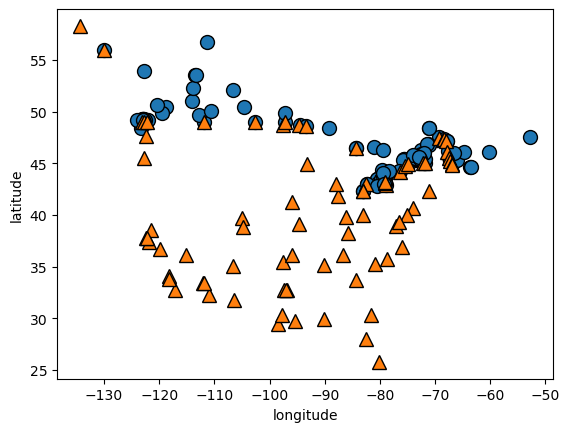

In [9]:
cities_df = pd.read_csv("canada_usa_cities.csv")
X_cities = cities_df[["longitude", "latitude"]]
y_cities = cities_df["country"]

mglearn.discrete_scatter(X_cities.iloc[:, 0], X_cities.iloc[:, 1], y_cities)
plt.xlabel("longitude")
plt.ylabel("latitude");

Here, we do the train-test splitting of the dataset.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_cities, y_cities, test_size=0.1, random_state=123
)

We create a function, display_tree, to visualize a decision tree for binary classification by generating a Graphviz representation of the tree. The function allows customization: if counts is set to True, it modifies the DOT output to display counts of samples at each node instead of the default values; otherwise, it omits these details.

In [11]:
# This is a helper function for plotting
def display_tree(feature_names, tree, counts=False):
    """For binary classification only"""
    dot = export_graphviz(
        tree,
        out_file=None,
        feature_names=feature_names,
        class_names=tree.classes_.astype(str),
        impurity=False,
    )
    # adapted from https://stackoverflow.com/questions/44821349/python-graphviz-remove-legend-on-nodes-of-decisiontreeclassifier
    # dot = re.sub('(\\\\nsamples = [0-9]+)(\\\\nvalue = \[[0-9]+, [0-9]+\])(\\\\nclass = [A-Za-z0-9]+)', '', dot)
    if counts:
        dot = re.sub("(samples = [0-9]+)\\\\n", "", dot)
        dot = re.sub("value", "counts", dot)
    else:
        dot = re.sub(
            "(\\\\nsamples = [0-9]+)(\\\\nvalue = \[[0-9]+, [0-9]+\])", "", dot
        )
        dot = re.sub(
            "(samples = [0-9]+)(\\\\nvalue = \[[0-9]+, [0-9]+\])\\\\n", "", dot
        )

    return graphviz.Source(dot)

In the next sections, we fit the model and display some graphs for Decision Tree.

In [12]:
tree = DecisionTreeClassifier(max_depth=1)
tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
pip install Image

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 841.7 kB/s  0:00:09 eta 0:00:01
  Created wheel for Image: filename=image-1.5.33-py2.py3-none-any.whl size=19554 sha256=f731d687cb02abbcaed7957353c88d66754a4c558c378bad7134f5d47f36f930
  Stored in directory: /Users/wilco/Library/Caches/pip/wheels/d3/1b/a8/8fecb075fe65c1bd04431aeb3e1562e41fe3d77f5df9288ae6
Successfully built Image
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [Image]32m2/4 [django]
Note: you may need to restart the kernel to use updated packages.


In [17]:
import image

In [18]:
toy_tree_viz = display_tree(X_train.columns, tree, counts=True)
Image(toy_tree_viz.pipe("png"))

NameError: name 'Image' is not defined

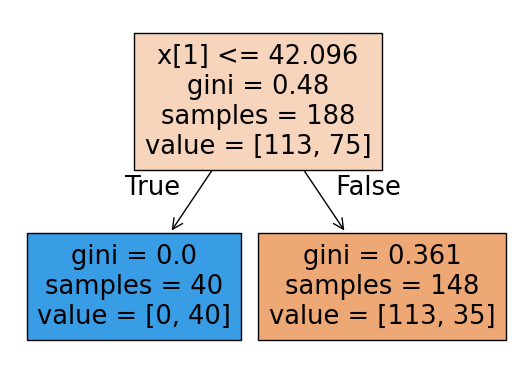

In [19]:
plt.figure()
plot_tree(tree, filled=True)
plt.show()

Here, we visualize the decision boundary of a trained decision tree classifier on a 2D feature space defined by longitude and latitude. The DecisionBoundaryDisplay.from_estimator function generates a plot showing the model's decision boundary based on the X_train dataset. A color map is created by mapping each label in y_train to a specific color, with `1` for 'Canada' and `0` for other values.

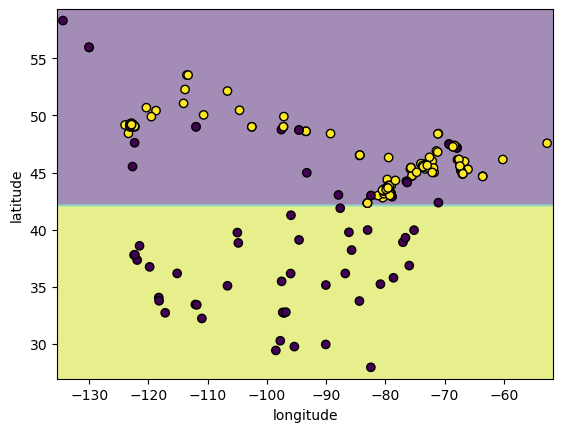

In [20]:
display = DecisionBoundaryDisplay.from_estimator(
    tree, X_train, response_method="predict",
    xlabel='longitude', ylabel='latitude',
    alpha=0.5)
colors = y_train.apply(lambda x: 1 if x in ['Canada'] else 0).tolist()
display.ax_.scatter(
    X_train['longitude'], X_train['latitude'], c=colors, edgecolor="black")
plt.show()

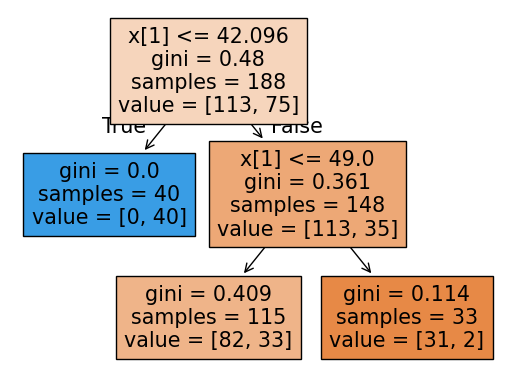

In [21]:
tree = DecisionTreeClassifier(max_depth=2)
tree.fit(X_train, y_train)

plot_tree(tree, filled=True)
plt.show()

This section of the code generates a visual representation of how a decision tree classifier distinguishes between different classes based on geographical coordinates (longitude and latitude). The decision boundary shows where the model predicts the class to change, and the scatter plot shows the actual data points, color-coded to highlight specific classes.

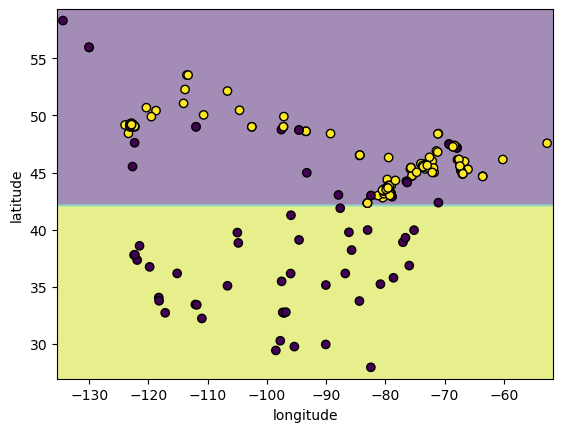

In [22]:
display = DecisionBoundaryDisplay.from_estimator(
    tree, X_train, response_method="predict",
    xlabel='longitude', ylabel='latitude',
    alpha=0.5)
colors = y_train.apply(lambda x: 1 if x in ['Canada'] else 0).tolist()
display.ax_.scatter(
    X_train['longitude'], X_train['latitude'], c=colors, edgecolor="black")
plt.show()

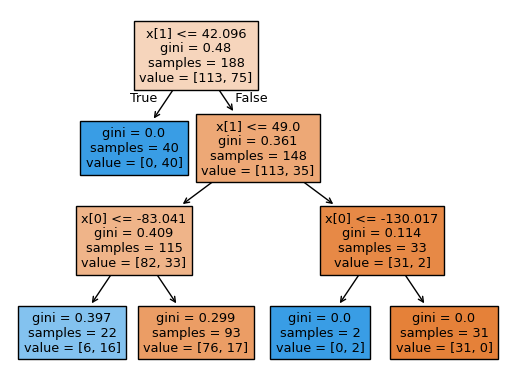

In [23]:
tree = DecisionTreeClassifier(max_depth=3)
tree.fit(X_train, y_train)

plot_tree(tree, filled=True)
plt.show()

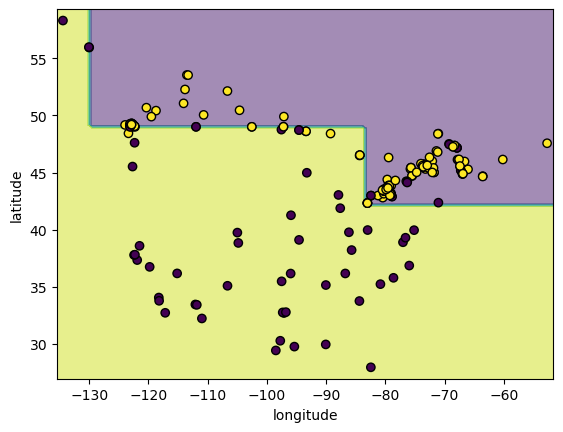

In [24]:
display = DecisionBoundaryDisplay.from_estimator(
    tree, X_train, response_method="predict",
    xlabel='longitude', ylabel='latitude',
    alpha=0.5)
colors = y_train.apply(lambda x: 1 if x in ['Canada'] else 0).tolist()
display.ax_.scatter(
    X_train['longitude'], X_train['latitude'], c=colors, edgecolor="black")
plt.show()

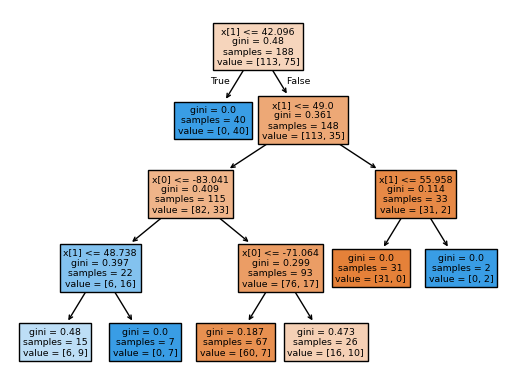

In [25]:
tree = DecisionTreeClassifier(max_depth=4)
tree.fit(X_train, y_train)

plot_tree(tree, filled=True)
plt.show()

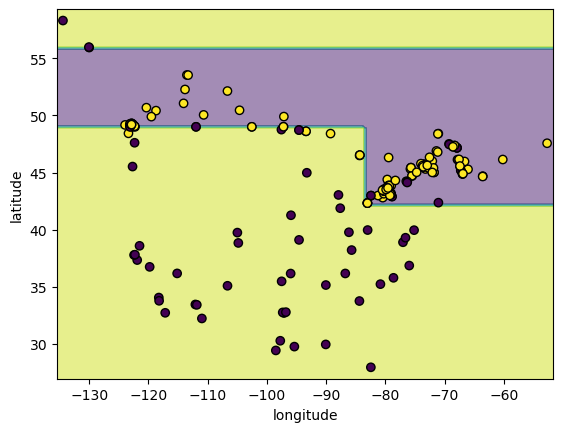

In [26]:
display = DecisionBoundaryDisplay.from_estimator(
    tree, X_train, response_method="predict",
    xlabel='longitude', ylabel='latitude',
    alpha=0.5)
colors = y_train.apply(lambda x: 1 if x in ['Canada'] else 0).tolist()
display.ax_.scatter(
    X_train['longitude'], X_train['latitude'], c=colors, edgecolor="black")
plt.show()

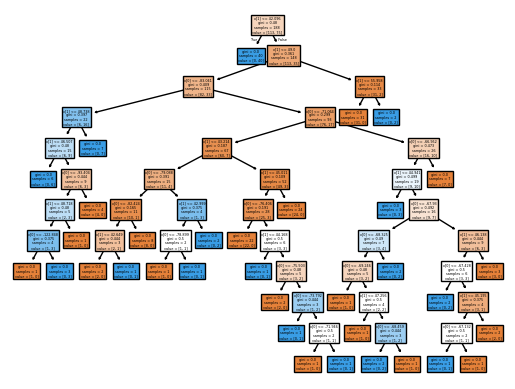

In [27]:
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)

plot_tree(tree, filled=True)
plt.show()

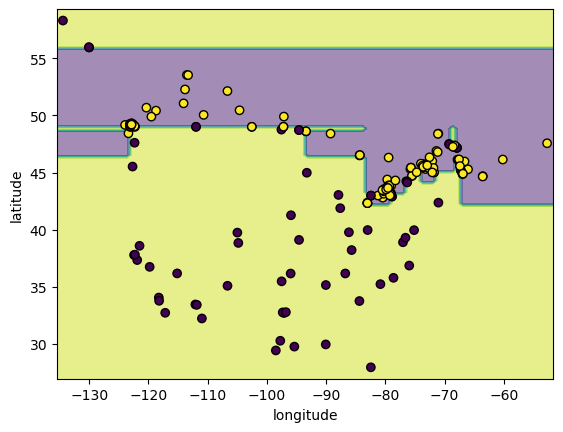

In [28]:
display = DecisionBoundaryDisplay.from_estimator(
    tree, X_train, response_method="predict",
    xlabel='longitude', ylabel='latitude',
    alpha=0.5)
colors = y_train.apply(lambda x: 1 if x in ['Canada'] else 0).tolist()
display.ax_.scatter(
    X_train['longitude'], X_train['latitude'], c=colors, edgecolor="black")
plt.show()

Decision trees also have a notion of feature importances. We can get the measure by using the feature_importances_attribute.

In [29]:
tree.feature_importances_

array([0.37623745, 0.62376255])

In [30]:
tree.feature_names_in_

array(['longitude', 'latitude'], dtype=object)

###In the next two sections, we will go over the Decision Tree Regressor and Classifier created from scratch.

#Decision Tree Regressor

In this section, we will go over the a decision tree regressor problem.

## Import tools

In [31]:
import numpy as np
import pandas as pd

## Get the data

For this section, we use the [NASA Airfoil Self-Noise](https://www.kaggle.com/datasets/fedesoriano/airfoil-selfnoise-dataset) dataset. Download the dataset from the provided link and add it to your working directory.

In [33]:
data = pd.read_csv("AirfoilSelfNoise.csv")
data.head(5)

,f,alpha,c,U_infinity,delta,SSPL
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


## Node class

In this section, we define a class named 'Node', which will represent each node in a decision tree regressor.

In [34]:
class Node_R():
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, var_red=None, value=None):
        ''' constructor '''

        # for decision node
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.var_red = var_red

        # for leaf node
        self.value = value

## Tree class

Here, we implement a Decision Tree Regressor from scratch. The DecisionTreeRegressor class starts by initializing the tree with parameters like min_samples_split and max_depth for controlling when the tree stops splitting. The main function is build_tree, which recursively splits the dataset by finding the best feature and threshold to minimize variance (variance reduction). The best split is determined by looping over features and thresholds, using functions like variance_reduction to measure the effectiveness of each split. The tree splits recursively until stopping conditions are met, forming either a decision node (if further splits are beneficial) or a leaf node (holding a predicted value). The fit function builds the tree using the provided dataset, while the predict function uses the constructed tree to make predictions on new data.

In [35]:
class DecisionTreeRegressor():
    def __init__(self, min_samples_split=2, max_depth=2):
        ''' constructor '''

        # initialize the root of the tree
        self.root = None

        # stopping conditions
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth

    def build_tree(self, dataset, curr_depth=0):
        ''' recursive function to build the tree '''

        X, Y = dataset[:,:-1], dataset[:,-1]
        num_samples, num_features = np.shape(X)
        best_split = {}
        # split until stopping conditions are met
        if num_samples>=self.min_samples_split and curr_depth<=self.max_depth:
            # find the best split
            best_split = self.get_best_split(dataset, num_samples, num_features)
            # check if information gain is positive
            if best_split["var_red"]>0:
                # recur left
                left_subtree = self.build_tree(best_split["dataset_left"], curr_depth+1)
                # recur right
                right_subtree = self.build_tree(best_split["dataset_right"], curr_depth+1)
                # return decision node
                return Node_R(best_split["feature_index"], best_split["threshold"],
                            left_subtree, right_subtree, best_split["var_red"])

        # compute leaf node
        leaf_value = self.calculate_leaf_value(Y)
        # return leaf node
        return Node_R(value=leaf_value)

    def get_best_split(self, dataset, num_samples, num_features):
        ''' function to find the best split '''

        # dictionary to store the best split
        best_split = {}
        max_var_red = -float("inf")
        # loop over all the features
        for feature_index in range(num_features):
            feature_values = dataset[:, feature_index]
            possible_thresholds = np.unique(feature_values)
            # loop over all the feature values present in the data
            for threshold in possible_thresholds:
                # get current split
                dataset_left, dataset_right = self.split(dataset, feature_index, threshold)
                # check if childs are not null
                if len(dataset_left)>0 and len(dataset_right)>0:
                    y, left_y, right_y = dataset[:, -1], dataset_left[:, -1], dataset_right[:, -1]
                    # compute information gain
                    curr_var_red = self.variance_reduction(y, left_y, right_y)
                    # update the best split if needed
                    if curr_var_red>max_var_red:
                        best_split["feature_index"] = feature_index
                        best_split["threshold"] = threshold
                        best_split["dataset_left"] = dataset_left
                        best_split["dataset_right"] = dataset_right
                        best_split["var_red"] = curr_var_red
                        max_var_red = curr_var_red

        # return best split
        return best_split

    def split(self, dataset, feature_index, threshold):
        ''' function to split the data '''

        dataset_left = np.array([row for row in dataset if row[feature_index]<=threshold])
        dataset_right = np.array([row for row in dataset if row[feature_index]>threshold])
        return dataset_left, dataset_right

    def variance_reduction(self, parent, l_child, r_child):
        ''' function to compute variance reduction '''

        weight_l = len(l_child) / len(parent)
        weight_r = len(r_child) / len(parent)
        reduction = np.var(parent) - (weight_l * np.var(l_child) + weight_r * np.var(r_child))
        return reduction

    def calculate_leaf_value(self, Y):
        ''' function to compute leaf node '''

        val = np.mean(Y)
        return val

    def print_tree(self, tree=None, indent=" "):
        ''' function to print the tree '''

        if not tree:
            tree = self.root

        if tree.value is not None:
            print(tree.value)

        else:
            print("X_"+str(tree.feature_index), "<=", tree.threshold, "?", tree.var_red)
            print("%sleft:" % (indent), end="")
            self.print_tree(tree.left, indent + indent)
            print("%sright:" % (indent), end="")
            self.print_tree(tree.right, indent + indent)

    def fit(self, X, Y):
        ''' function to train the tree '''

        dataset = np.concatenate((X, Y), axis=1)
        self.root = self.build_tree(dataset)

    def make_prediction(self, x, tree):
        ''' function to predict new dataset '''

        if tree.value!=None: return tree.value
        feature_val = x[tree.feature_index]
        if feature_val<=tree.threshold:
            return self.make_prediction(x, tree.left)
        else:
            return self.make_prediction(x, tree.right)

    def predict(self, X):
        ''' function to predict a single data point '''

        preditions = [self.make_prediction(x, self.root) for x in X]
        return preditions

## Train-Test split

In [36]:
X = data.iloc[:, :-1].values
Y = data.iloc[:, -1].values.reshape(-1,1)
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.2, random_state=41)

## Fit the model

In [37]:
regressor = DecisionTreeRegressor(min_samples_split=3, max_depth=3)
regressor.fit(X_train,Y_train)
regressor.print_tree()

X_0 <= 3150.0 ? 7.132048702017748
 left:X_4 <= 0.0337792 ? 3.590330569067664
  left:X_3 <= 55.5 ? 1.17898999813184
    left:X_4 <= 0.00251435 ? 1.614396721819876
        left:128.9919833333333
        right:125.90953579676673
    right:X_1 <= 15.4 ? 2.2342245360792994
        left:129.39160280373832
        right:123.80422222222222
  right:X_0 <= 1250.0 ? 9.970884020498868
    left:X_4 <= 0.0483159 ? 6.35527515982486
        left:124.38024528301887
        right:118.30039999999998
    right:X_3 <= 39.6 ? 5.036286657241031
        left:113.58091666666667
        right:118.07284615384616
 right:X_4 <= 0.00146332 ? 29.08299210506528
  left:X_0 <= 8000.0 ? 11.886497073996964
    left:X_2 <= 0.0508 ? 7.608945827689519
        left:134.04247500000002
        right:127.33581818181818
    right:X_4 <= 0.00076193 ? 10.6229193224008
        left:128.94078571428574
        right:122.40768750000001
  right:X_4 <= 0.0229028 ? 5.638575922510643
    left:X_0 <= 6300.0 ? 5.985051045988914
        left

## Test the model

In [38]:
Y_pred = regressor.predict(X_test)
from sklearn.metrics import mean_squared_error
np.sqrt(mean_squared_error(Y_test, Y_pred))

np.float64(4.851358097184457)

# Decision Tree Classifier

## Get the data

In this section, we use the [Iris](https://www.kaggle.com/datasets/uciml/iris) dataset. Download the dataset from the provided link and add it to your working directory.

In [39]:
col_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'type']
data_Iris = pd.read_csv("Iris.csv", skiprows=1, header=None, names=col_names)
data_Iris.head(10)

FileNotFoundError: [Errno 2] No such file or directory: 'Iris.csv'

## Node class

In this section, we define a class named 'Node', which will represent each node in a decision tree classifier.

In [24]:
class Node_C():
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, info_gain=None, value=None):
        ''' constructor '''

        # for decision node
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.info_gain = info_gain

        # for leaf node
        self.value = value

## Tree class

Here, we implement a Decision Tree Classifier from scratch, where the DecisionTreeClassifier class builds and uses a binary decision tree to classify data points. The tree is constructed using the build_tree method, which recursively finds the best feature and threshold to split the data by maximizing information gain (calculated using either Gini index or entropy). The splitting continues until a stopping condition—based on a minimum number of samples or maximum tree depth—is met. Each node is either a decision node (storing the feature and threshold) or a leaf node (storing the predicted class). The fit method builds the tree using training data, while the predict method classifies new data points by traversing the tree based on feature values.

In [25]:
class DecisionTreeClassifier():
    def __init__(self, min_samples_split=2, max_depth=2):
        ''' constructor '''

        # initialize the root of the tree
        self.root = None

        # stopping conditions
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth

    def build_tree(self, dataset, curr_depth=0):
        ''' recursive function to build the tree '''

        X, Y = dataset[:,:-1], dataset[:,-1]
        num_samples, num_features = np.shape(X)

        # split until stopping conditions are met
        if num_samples>=self.min_samples_split and curr_depth<=self.max_depth:
            # find the best split
            best_split = self.get_best_split(dataset, num_samples, num_features)
            # check if information gain is positive
            if best_split["info_gain"]>0:
                # recur left
                left_subtree = self.build_tree(best_split["dataset_left"], curr_depth+1)
                # recur right
                right_subtree = self.build_tree(best_split["dataset_right"], curr_depth+1)
                # return decision node
                return Node_C(best_split["feature_index"], best_split["threshold"],
                            left_subtree, right_subtree, best_split["info_gain"])

        # compute leaf node
        leaf_value = self.calculate_leaf_value(Y)
        # return leaf node
        return Node_C(value=leaf_value)

    def get_best_split(self, dataset, num_samples, num_features):
        ''' function to find the best split '''

        # dictionary to store the best split
        best_split = {}
        max_info_gain = -float("inf")

        # loop over all the features
        for feature_index in range(num_features):
            feature_values = dataset[:, feature_index]
            possible_thresholds = np.unique(feature_values)
            # loop over all the feature values present in the data
            for threshold in possible_thresholds:
                # get current split
                dataset_left, dataset_right = self.split(dataset, feature_index, threshold)
                # check if childs are not null
                if len(dataset_left)>0 and len(dataset_right)>0:
                    y, left_y, right_y = dataset[:, -1], dataset_left[:, -1], dataset_right[:, -1]
                    # compute information gain
                    curr_info_gain = self.information_gain(y, left_y, right_y, "gini")
                    # update the best split if needed
                    if curr_info_gain>max_info_gain:
                        best_split["feature_index"] = feature_index
                        best_split["threshold"] = threshold
                        best_split["dataset_left"] = dataset_left
                        best_split["dataset_right"] = dataset_right
                        best_split["info_gain"] = curr_info_gain
                        max_info_gain = curr_info_gain

        # return best split
        return best_split

    def split(self, dataset, feature_index, threshold):
        ''' function to split the data '''

        dataset_left = np.array([row for row in dataset if row[feature_index]<=threshold])
        dataset_right = np.array([row for row in dataset if row[feature_index]>threshold])
        return dataset_left, dataset_right

    def information_gain(self, parent, l_child, r_child, mode="entropy"):
        ''' function to compute information gain '''

        weight_l = len(l_child) / len(parent)
        weight_r = len(r_child) / len(parent)
        if mode=="gini":
            gain = self.gini_index(parent) - (weight_l*self.gini_index(l_child) + weight_r*self.gini_index(r_child))
        else:
            gain = self.entropy(parent) - (weight_l*self.entropy(l_child) + weight_r*self.entropy(r_child))
        return gain

    def entropy(self, y):
        ''' function to compute entropy '''

        class_labels = np.unique(y)
        entropy = 0
        for cls in class_labels:
            p_cls = len(y[y == cls]) / len(y)
            entropy += -p_cls * np.log2(p_cls)
        return entropy

    def gini_index(self, y):
        ''' function to compute gini index '''

        class_labels = np.unique(y)
        gini = 0
        for cls in class_labels:
            p_cls = len(y[y == cls]) / len(y)
            gini += p_cls**2
        return 1 - gini

    def calculate_leaf_value(self, Y):
        ''' function to compute leaf node '''

        Y = list(Y)
        return max(Y, key=Y.count)

    def print_tree(self, tree=None, indent=" "):
        ''' function to print the tree '''

        if not tree:
            tree = self.root

        if tree.value is not None:
            print(tree.value)

        else:
            print("X_"+str(tree.feature_index), "<=", tree.threshold, "?", tree.info_gain)
            print("%sleft:" % (indent), end="")
            self.print_tree(tree.left, indent + indent)
            print("%sright:" % (indent), end="")
            self.print_tree(tree.right, indent + indent)

    def fit(self, X, Y):
        ''' function to train the tree '''

        dataset = np.concatenate((X, Y), axis=1)
        self.root = self.build_tree(dataset)

    def predict(self, X):
        ''' function to predict new dataset '''

        preditions = [self.make_prediction(x, self.root) for x in X]
        return preditions

    def make_prediction(self, x, tree):
        ''' function to predict a single data point '''

        if tree.value!=None: return tree.value
        feature_val = x[tree.feature_index]
        if feature_val<=tree.threshold:
            return self.make_prediction(x, tree.left)
        else:
            return self.make_prediction(x, tree.right)

## Train-Test split

In [27]:
X = data_Iris.iloc[:, :-1].values
Y = data_Iris.iloc[:, -1].values.reshape(-1,1)
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.2, random_state=41)

## Fit the model

In [28]:
classifier = DecisionTreeClassifier(min_samples_split=3, max_depth=3)
classifier.fit(X_train,Y_train)
classifier.print_tree()

X_2 <= 1.9 ? 0.33741385372714494
 left:Iris-setosa
 right:X_3 <= 1.5 ? 0.427106638180289
  left:X_2 <= 4.9 ? 0.05124653739612173
    left:Iris-versicolor
    right:Iris-virginica
  right:X_2 <= 5.0 ? 0.019631171921475288
    left:X_1 <= 2.8 ? 0.20833333333333334
        left:Iris-virginica
        right:Iris-versicolor
    right:Iris-virginica


## Test the model

In [29]:
Y_pred = classifier.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(Y_test, Y_pred)

0.9333333333333333